# HALO NYC methane inversion — step-by-step walkthrough

A single-flight Bayesian flux inversion end to end, with each stage exposed for inspection and tuning. Built on the generic `goe` framework (from the separate `goe-inversion` project) plus the HALO-specific adapters in `halo_oe`.

**Model.** Each receptor is a column-averaged XCH4 observation = background + enhancement from surface fluxes through a precomputed Jacobian `H`:

$$x_{\mathrm{obs}} = x_{\mathrm{bg}} + H f + \varepsilon,\qquad \hat{x} = x_a + S_a H^\top(H S_a H^\top + R)^{-1}(z - H x_a),\quad z = x_{\mathrm{obs}} - x_{\mathrm{bg}}$$

**Inventories.** EDGAR, EPA, Pittsburgh are *alternative* complete inventories of the same emissions — never summed. One inversion uses one as the prior (steps 7–10); step 11 compares all three; step 12 decomposes one inventory into emission super-categories.

**All settings come from `halo_oe/config.ini`**, the same file the `run_halo.py` CLI uses.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

BAYES_OPT = os.path.dirname(os.path.dirname(os.path.abspath('halo_inversion_walkthrough.ipynb')))
if BAYES_OPT not in sys.path:
    sys.path.insert(0, BAYES_OPT)
import halo_oe  # noqa: F401

from goe import (GaussianLinearProblem, BlockDiagonalCovariance, DiagonalCovariance,
                 StateSpace, solve, reduced_chi_square)
from goe.config import Config
from adapters.gridded_state import GriddedState
from adapters.jacobian_operator import JacobianFile
from adapters.scaling_blocks import category_blocks, offset_block
from adapters.covariance_builders import build_spatial_covariance
from adapters.observations import build_observations
from halo_oe.emissions import category_priors_on_grid
from halo_oe.background import flight_background, domain_insensitive_mask
from halo_oe.flux import estimate_fluxes
from halo_oe.pipeline import InversionContext, invert, flight_paths

CONFIG_PATH = os.path.join(BAYES_OPT, 'halo_oe', 'config.ini')
cfg = Config(CONFIG_PATH)
_cfgdir = os.path.dirname(CONFIG_PATH)
def _resolve(p):
    return p if os.path.isabs(p) else os.path.normpath(os.path.join(_cfgdir, p))

# This walkthrough illustrates ONE flight; multi-flight assimilation is run from the
# CLI (`run_halo.py --flights ...`) or `load_context(cfg, ..., flights=[...])`.
FLIGHT_ID, _jacpath = flight_paths(cfg)[0]            # first configured flight
JAC_PATH  = _resolve(_jacpath)
EMIS_PATH = _resolve(cfg.get('emissions', 'path'))
BBOX      = cfg.get_literal('domain', 'bbox')
INVENTORY = cfg.get('emissions', 'inventory', default='pitt')
COMPARE   = [s.strip() for s in cfg.get('emissions', 'compare', default='edgar,epa,pitt').split(',')]
METHOD    = cfg.get('decomposition', 'method', default='category_fields')

DEGREE            = cfg.get_int('background', 'degree', default=1)
ENVELOPE_QUANTILE = cfg.get_float('background', 'envelope_quantile', default=0.25)
N_ITER            = cfg.get_int('background', 'n_iter', default=5)
DOMAIN_SENS_Q     = cfg.get_float('background', 'domain_sensitivity_quantile', default=1.0)
SCALAR_STDDEV     = cfg.get_float('prior', 'scalar_stddev', default=0.5)
CORR_KM           = cfg.get_float('prior', 'correlation_length_km', default=5.0)
OBS_STDDEV        = cfg.get_float('observations', 'error_stddev', default=0.02)
N_OFFSETS         = cfg.get_int('offset', 'n_groups', default=1)
OFFSET_STDDEV     = cfg.get_float('offset', 'stddev', default=0.02)

print('config   :', CONFIG_PATH, '| flight:', FLIGHT_ID)
print('primary inventory:', INVENTORY, '| compared:', COMPARE, '| decomposition method:', METHOD)
print(f'bbox={BBOX}  corr_km={CORR_KM}  scalar_sd={SCALAR_STDDEV}  obs_sd={OBS_STDDEV}  '
      f'offset_sd={OFFSET_STDDEV}  bg_domain_sens_q={DOMAIN_SENS_Q}')

config   : /Volumes/Expansion/halo-nyc/bayes_opt/halo_oe/config.ini | flight: 20230726_1
primary inventory: pitt | compared: ['edgar', 'epa', 'pitt'] | decomposition method: category_fields
bbox=[40.4, 41.1, -74.3, -73.5]  corr_km=5.0  scalar_sd=0.5  obs_sd=0.02  offset_sd=0.02  bg_domain_sens_q=0.5


## 1. Open the Jacobian (metadata only)

Opening reads only small coordinate/receptor variables; the multi-gigabyte array is read lazily (only in step 6).

In [2]:
jf = JacobianFile(JAC_PATH)
grid = jf.grid
obs = jf.receptor_obs
rlat, rlon = jf.receptor_lat, jf.receptor_lon
print(f'receptors {jf.n_receptors} | grid {grid.shape} ({grid.n_cells:,} cells) | '
      f'XCH4 mean {obs.mean():.4f}, range [{obs.min():.4f}, {obs.max():.4f}] ppm')

receptors 1271 | grid (1666, 1666) (2,775,556 cells) | XCH4 mean 2.0148, range [1.9518, 2.0992] ppm


## 2. Inspect the observations

Receptors trace the flight track; color is observed column XCH4 — elevated over/downwind of the urban core.

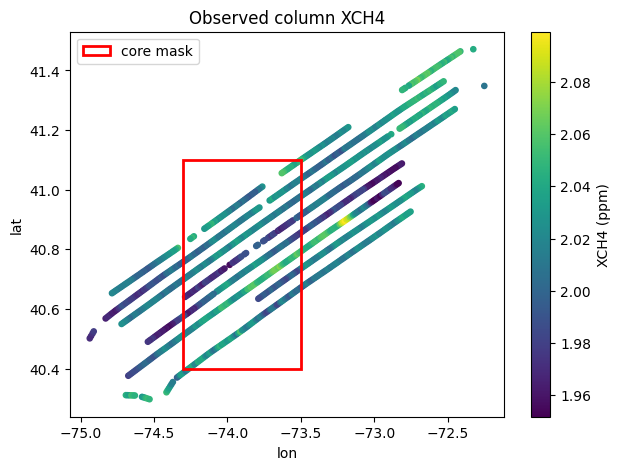

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(rlon, rlat, c=obs, s=14, cmap='viridis')
ax.add_patch(plt.Rectangle((BBOX[2], BBOX[0]), BBOX[3]-BBOX[2], BBOX[1]-BBOX[0],
                           fill=False, ec='red', lw=2, label='core mask'))
ax.set_xlabel('lon'); ax.set_ylabel('lat'); ax.set_title('Observed column XCH4'); ax.legend(loc='upper left')
fig.colorbar(sc, label='XCH4 (ppm)'); plt.show()

## 3. Optimize the background → enhancements

Remove the inflow/free-tropospheric background via a **per-flight, lower-envelope plane** in (lat, lon): per-flight (day/time), lower-envelope (tracks clean air), degree 1 (too few DOF to chase the plume). Enhancement assimilated is `z = obs - background`.

> This first fit uses **all** receptors for illustration. Step 6b refits the background to **exclude receptors sensitive to the inversion domain** (whose columns carry the enhancement we are retrieving), so the baseline is not contaminated by in-domain signal.

In [4]:
bg = flight_background(rlat, rlon, obs, degree=DEGREE, quantile=ENVELOPE_QUANTILE, n_iter=N_ITER)
z = obs - bg
print(f'background mean {bg.mean():.4f}, range [{bg.min():.4f}, {bg.max():.4f}] ppm')
print(f'enhancement z mean {z.mean():+.4f}, range [{z.min():+.4f}, {z.max():+.4f}] ppm, {np.mean(z>=0)*100:.0f}% positive')

background mean 1.9767, range [1.9237, 2.0224] ppm
enhancement z mean +0.0380, range [-0.0246, +0.1355] ppm, 89% positive


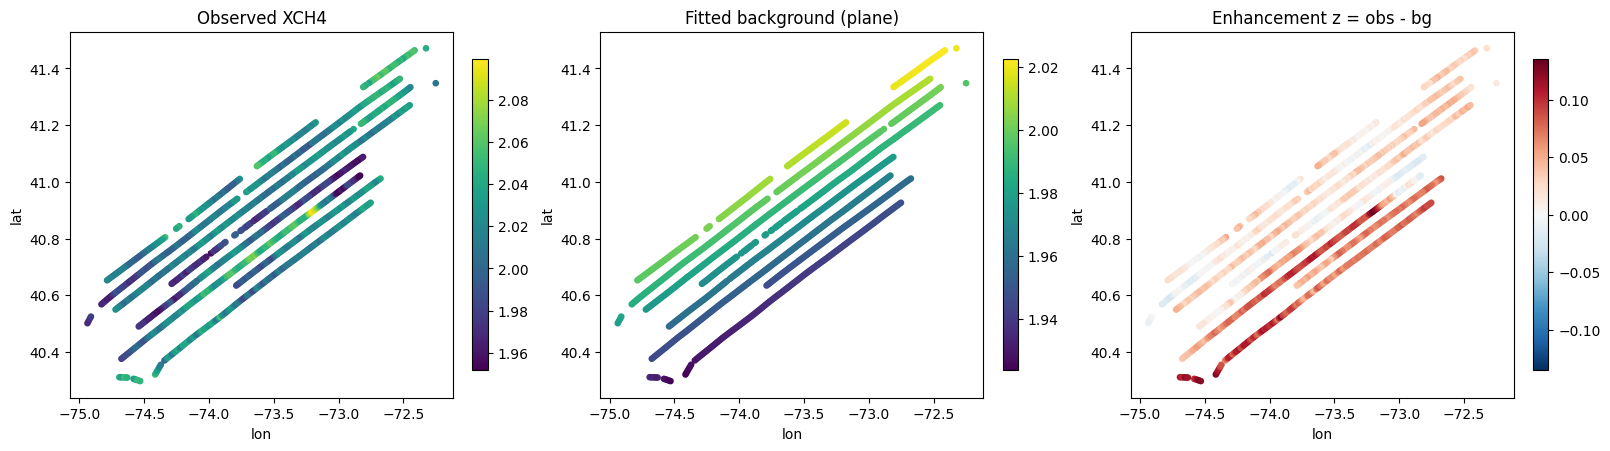

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)
for a, (title, val, cmap) in zip(ax, [('Observed XCH4', obs, 'viridis'),
        ('Fitted background (plane)', bg, 'viridis'), ('Enhancement z = obs - bg', z, 'RdBu_r')]):
    vlim = None if cmap=='viridis' else max(abs(z.min()), abs(z.max()))
    kw = dict(vmin=-vlim, vmax=vlim) if vlim else {}
    s = a.scatter(rlon, rlat, c=val, s=14, cmap=cmap, **kw)
    a.set_title(title); a.set_xlabel('lon'); a.set_ylabel('lat'); fig.colorbar(s, ax=a, shrink=0.85)
plt.show()

## 4. Domain mask (state grid)

Solve for fluxes only inside the NYC core box (`BBOX`); the rest is held at the prior.

In [6]:
mask = grid.bbox_mask(*BBOX)
core = GriddedState(grid, mask, name='core')
print(f'active core cells: {core.n_active:,} of {grid.n_cells:,}')
rows = np.where(mask.any(1))[0]; cols = np.where(mask.any(0))[0]
r0, r1, c0, c1 = rows[0], rows[-1]+1, cols[0], cols[-1]+1
EXTENT = [grid.lon[c0], grid.lon[c1-1], grid.lat[r0], grid.lat[r1-1]]
def crop(field2d):
    return field2d[r0:r1, c0:c1]

active core cells: 6,942 of 2,775,556


## 5. Prior emission fields (alternative inventories)

Each inventory in `COMPARE` is summed over sub-categories and regridded onto the Jacobian grid. These are *alternative* estimates — the primary inversion uses only `INVENTORY`.

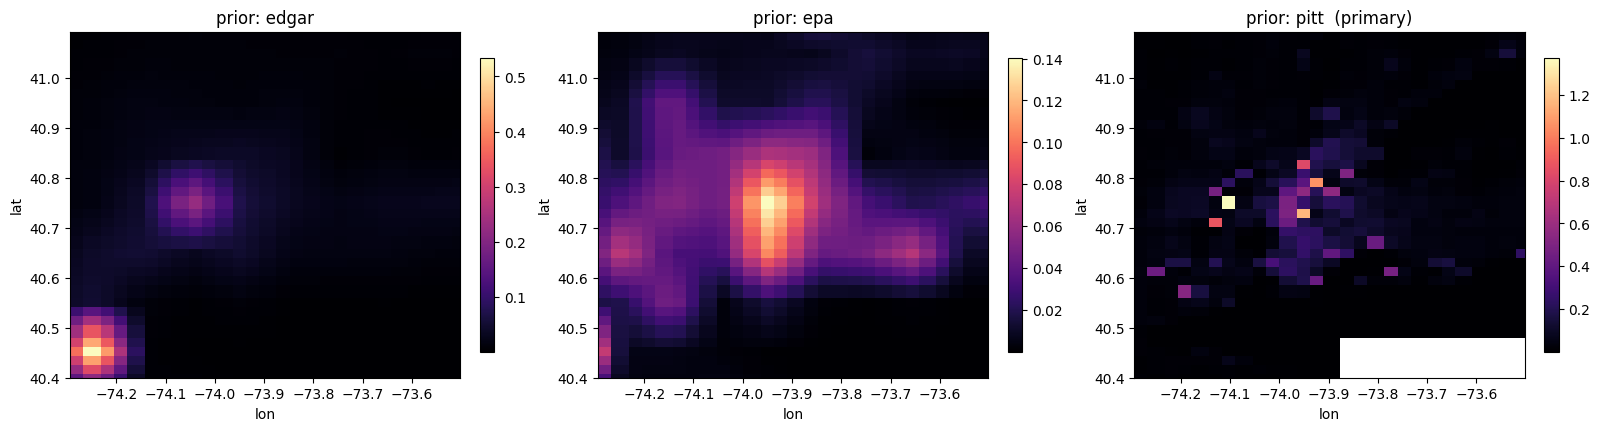

In [7]:
priors = category_priors_on_grid(EMIS_PATH, grid, sources=tuple(COMPARE))
fig, ax = plt.subplots(1, len(priors), figsize=(5.3*len(priors), 4.2), constrained_layout=True)
ax = np.atleast_1d(ax)
for a, name in zip(ax, priors):
    f = crop(priors[name]).copy(); f[f <= 0] = np.nan
    im = a.imshow(f, origin='lower', extent=EXTENT, aspect='auto', cmap='magma')
    a.set_title(f'prior: {name}' + ('  (primary)' if name == INVENTORY else ''))
    a.set_xlabel('lon'); a.set_ylabel('lat'); fig.colorbar(im, ax=a, shrink=0.85)
plt.show()

## 6. Forward operator  ⏳ (reads the large Jacobian, once)

Stream the Jacobian once, keep the masked columns, return `H` over the active cells. This `base` operator is reused everywhere below.

In [8]:
base = jf.operator(active=core.active, in_memory=cfg.get_bool('jacobian', 'in_memory', default=True),
                   row_chunk=cfg.get_int('jacobian', 'row_chunk', default=24))
print(f'forward operator H : {base.shape[0]} obs x {base.shape[1]} active cells')

forward operator H : 1271 obs x 6942 active cells


## 6b. Keep in-domain data out of the background

The background should represent **inflow air the inversion domain does not influence** — otherwise the in-domain enhancement we are retrieving leaks into the baseline it is subtracted from (circular, and it suppresses the signal). For column observations, "in-domain" is not a receptor's lat/lon but whether its **Jacobian footprint touches the masked cells**. We measure that as each receptor's **domain sensitivity = row sum of the masked `H`**, and **refit the background using only the least-sensitive receptors** (`[background] domain_sensitivity_quantile`). The surface is still evaluated at every receptor. This redefines `bg`/`z` used from here on.

> The `bc` offset block absorbs a *uniform* background shift, so the flux total moves only modestly; the correction matters most for the background's spatial gradient and for tighter/no offset.

background fit restricted to 636 of 1271 domain-insensitive receptors (q=0.5)
background mean: all-receptors 1.9767 -> restricted 1.9683 (-0.0084 ppm)
over in-domain (top-25% sensitivity) receptors: 1.9609 -> 1.9476 (enhancement +0.0133 ppm larger)


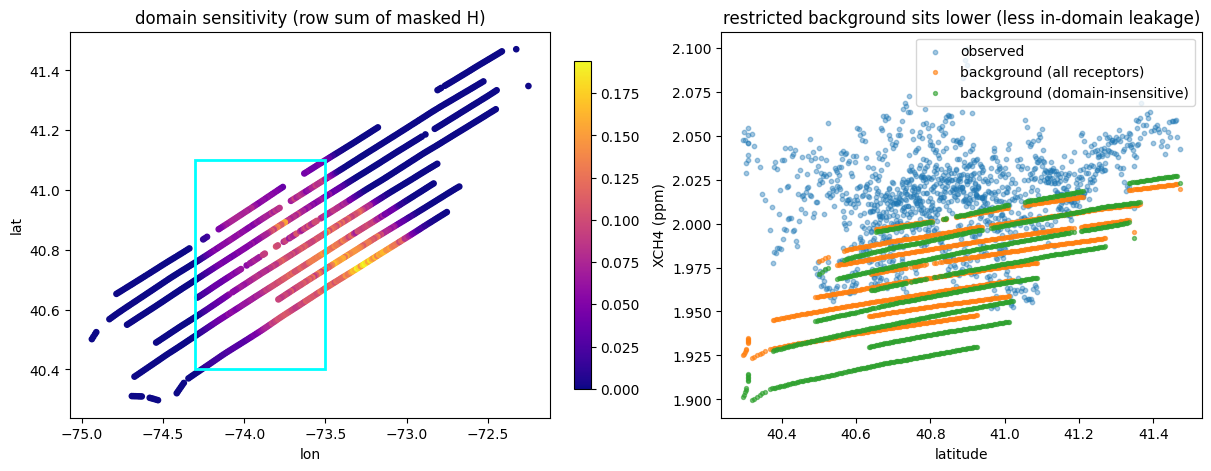

In [9]:
# domain sensitivity of each receptor = row sum of the masked Jacobian
# (column response to a unit uniform flux over the active cells)
domain_sensitivity = base.matvec(np.ones(core.n_active))
bg_all = bg  # the step-3 fit using all receptors

if DOMAIN_SENS_Q < 1.0:
    fit_mask = domain_insensitive_mask(domain_sensitivity, DOMAIN_SENS_Q)
    bg = flight_background(rlat, rlon, obs, degree=DEGREE, quantile=ENVELOPE_QUANTILE,
                           n_iter=N_ITER, fit_mask=fit_mask)
    print(f'background fit restricted to {fit_mask.sum()} of {len(obs)} '
          f'domain-insensitive receptors (q={DOMAIN_SENS_Q})')
else:
    print('domain-sensitivity restriction disabled (q=1.0): using all receptors')

z = obs - bg
hi = domain_sensitivity > np.quantile(domain_sensitivity, 0.75)   # most in-domain receptors
print(f'background mean: all-receptors {bg_all.mean():.4f} -> restricted {bg.mean():.4f} '
      f'({bg.mean()-bg_all.mean():+.4f} ppm)')
print(f'over in-domain (top-25% sensitivity) receptors: {bg_all[hi].mean():.4f} -> {bg[hi].mean():.4f} '
      f'(enhancement {bg_all[hi].mean()-bg[hi].mean():+.4f} ppm larger)')

# visualize which receptors anchored the (restricted) background
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
s0 = ax[0].scatter(rlon, rlat, c=domain_sensitivity, s=14, cmap='plasma')
ax[0].add_patch(plt.Rectangle((BBOX[2], BBOX[0]), BBOX[3]-BBOX[2], BBOX[1]-BBOX[0], fill=False, ec='cyan', lw=2))
ax[0].set_title('domain sensitivity (row sum of masked H)'); fig.colorbar(s0, ax=ax[0], shrink=0.85)
ax[1].scatter(rlat, obs, s=10, alpha=0.4, label='observed')
ax[1].scatter(rlat, bg_all, s=8, alpha=0.6, label='background (all receptors)')
ax[1].scatter(rlat, bg, s=8, alpha=0.6, label='background (domain-insensitive)')
ax[1].set_xlabel('latitude'); ax[1].set_ylabel('XCH4 (ppm)'); ax[1].legend()
ax[1].set_title('restricted background sits lower (less in-domain leakage)')
for a in [ax[0]]: a.set_xlabel('lon'); a.set_ylabel('lat')
plt.show()

## 7. State + prior (primary inventory)

State = a per-cell scalar field on the primary inventory total (`H·diag(prior)`) + a per-flight background offset. Scalar block gets a compact-support spatial prior; the offset gets a tight prior.

In [10]:
cat_blocks, cat_ops = category_blocks(core, base, {INVENTORY: priors[INVENTORY]})
state_blocks = list(cat_blocks); operators = dict(cat_ops)
cov_blocks = [build_spatial_covariance(core, SCALAR_STDDEV, CORR_KM)]
if N_OFFSETS > 0:
    assignments = (np.zeros(jf.n_receptors, dtype=int) if N_OFFSETS == 1
                   else np.arange(jf.n_receptors) % N_OFFSETS)
    off_blk, off_op = offset_block(assignments, n_groups=N_OFFSETS, name='bc')
    state_blocks.append(off_blk); operators['bc'] = off_op
    cov_blocks.append(DiagonalCovariance.isotropic(N_OFFSETS, OFFSET_STDDEV**2))
state = StateSpace(state_blocks)
H = state.block_column(operators)
Sa = BlockDiagonalCovariance(cov_blocks)
xa = state.fill(0.0, **{b.name: (0.0 if b.name == 'bc' else 1.0) for b in state.blocks})
obs_data = build_observations(obs, error_stddev=OBS_STDDEV, baseline=bg)
print('state blocks:', [(b.name, b.size) for b in state.blocks], '-> dim', state.size)

state blocks: [('pitt', 6942), ('bc', 1)] -> dim 6943


## 8. Solve

Observation-space form is chosen automatically. Reduced chi-square near 1 = well-scaled errors.

In [11]:
problem = GaussianLinearProblem(H=H, z=obs_data.z, xa=xa, Sa=Sa, R=obs_data.R)
posterior = solve(problem)
print(f'inventory {INVENTORY} | {posterior.strategy}-space | reduced chi2 {reduced_chi_square(problem, posterior):.3f}')
if 'bc' in state.names:
    print(f'fitted background offset (bc): {state.unpack(posterior.mean)["bc"][0]:+.4f} ppm')

inventory pitt | observation-space | reduced chi2 3.211
fitted background offset (bc): +0.0425 ppm


## 8b. Model-data mismatch and error tuning

A diagonal `R` assumes every receptor's error is independent — but adjacent 1 km receptors share heavily overlapping column footprints, so their representation+transport errors are **correlated along-track**. `obs_error.build_obs_error_covariance` builds `R = diag(measurement) + correlated MDM` as a single sparse covariance. Below we re-solve with it and compare reduced chi-square: accounting for the correlation typically changes chi-square *far more* than rescaling the diagonal, because it stops the inversion from treating correlated residuals as many independent constraints.

The error magnitudes are hyperparameters, fit from the data by `goe.tuning`: the Desroziers `r_scale` and the marginal-likelihood-optimal `alpha_R` indicate how to scale `R` toward reduced chi-square ≈ 1 (the `run_halo.py --tune` flag reports the same). With one flight the `R`/`Sa` split is weakly identified (low DOFS), so we tune `R` only here.

reduced chi-square:  diagonal R 3.211   ->   component-wise correlated R 0.622
(correlation recognizes adjacent receptors are not independent -> smaller effective misfit)

Desroziers r_scale 2.517  (>1 => assumed R too small)


max-likelihood alpha_R 0.618  -> scale mdm/measurement stddev by 0.786 toward reduced chi-square ~ 1


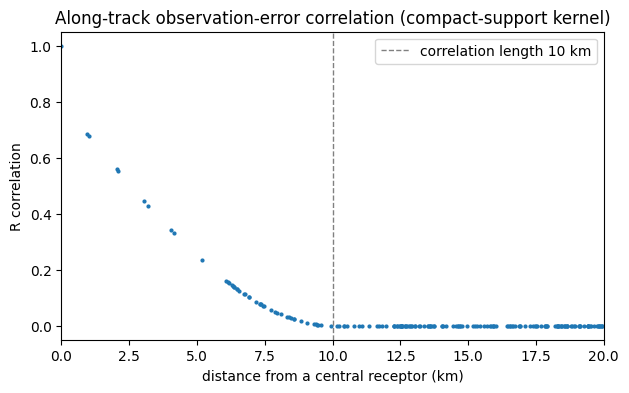

In [12]:
from halo_oe.obs_error import build_obs_error_covariance, receptors_to_km
from goe import desroziers_diagnostics, tune_variance_scales

# component-wise R: independent measurement variance + along-track-correlated MDM
R_comp = build_obs_error_covariance(rlat, rlon, cfg)
prob_corr = GaussianLinearProblem(H=H, z=obs_data.z, xa=xa, Sa=Sa, R=R_comp)
post_corr = solve(prob_corr)
chi_diag = reduced_chi_square(problem, posterior)
chi_corr = reduced_chi_square(prob_corr, post_corr)
print(f'reduced chi-square:  diagonal R {chi_diag:.3f}   ->   component-wise correlated R {chi_corr:.3f}')
print('(correlation recognizes adjacent receptors are not independent -> smaller effective misfit)')

# error tuning on the correlated-R problem (non-destructive: prints suggestions)
dz = desroziers_diagnostics(prob_corr, post_corr)
print(f'\nDesroziers r_scale {dz["r_scale"]:.3f}  (>1 => assumed R too small)')
vr = tune_variance_scales(prob_corr, tune_Sa=False, tune_R=True)
print(f'max-likelihood alpha_R {vr.alpha_R:.3f}  -> scale mdm/measurement stddev by '
      f'{vr.alpha_R**0.5:.3f} toward reduced chi-square ~ 1')

# illustrate the along-track correlation: R correlation of a central receptor vs distance
xy = receptors_to_km(rlat, rlon)
i0 = int(np.argmin(np.linalg.norm(xy - xy.mean(0), axis=1)))   # a central receptor
Rrow = np.asarray(R_comp.to_dense()[i0])
dist = np.linalg.norm(xy - xy[i0], axis=1)
corr = Rrow / Rrow[i0]
o = np.argsort(dist)
mdm_len = cfg.get_float('observations', 'mdm_correlation_length_km', default=10.0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dist[o], corr[o], '.', ms=4)
ax.axvline(mdm_len, color='gray', ls='--', lw=1, label=f'correlation length {mdm_len:.0f} km')
ax.set_xlabel('distance from a central receptor (km)'); ax.set_ylabel('R correlation')
ax.set_title('Along-track observation-error correlation (compact-support kernel)')
ax.set_xlim(0, max(2 * mdm_len, 5)); ax.legend(); plt.show()

## 8c. Flag outlier observations

Observations whose mismatch with the model is far larger than the expected error are usually gross errors (bad retrievals, mis-located data); leaving them in biases the posterior fluxes. We flag them by their **normalized residual** and (in the pipeline) drop them and re-solve. The default `innovation` check normalizes by the *full* expected mismatch `sqrt(diag(H Sa Hᵀ + R))` — the proper gross-error test, robust to the loose prior and to the fit partly hiding an outlier (`posterior` normalizes by `sqrt(diag R)` only).

The flag is per observation, so you can map it and save it. The pipeline returns it as `res.outlier_mask` (when `[observations] outlier_threshold > 0`), and `run_halo.py` writes it — with receptor lat/lon/obs — to the output netCDF as `outlier_flag`.

42 of 1271 receptors flagged (|innovation residual| > 4.0)
`outlier_mask` is the per-receptor flag (save/plot it). The pipeline returns it as
res.outlier_mask, and run_halo.py writes it to the output netCDF as 'outlier_flag'.


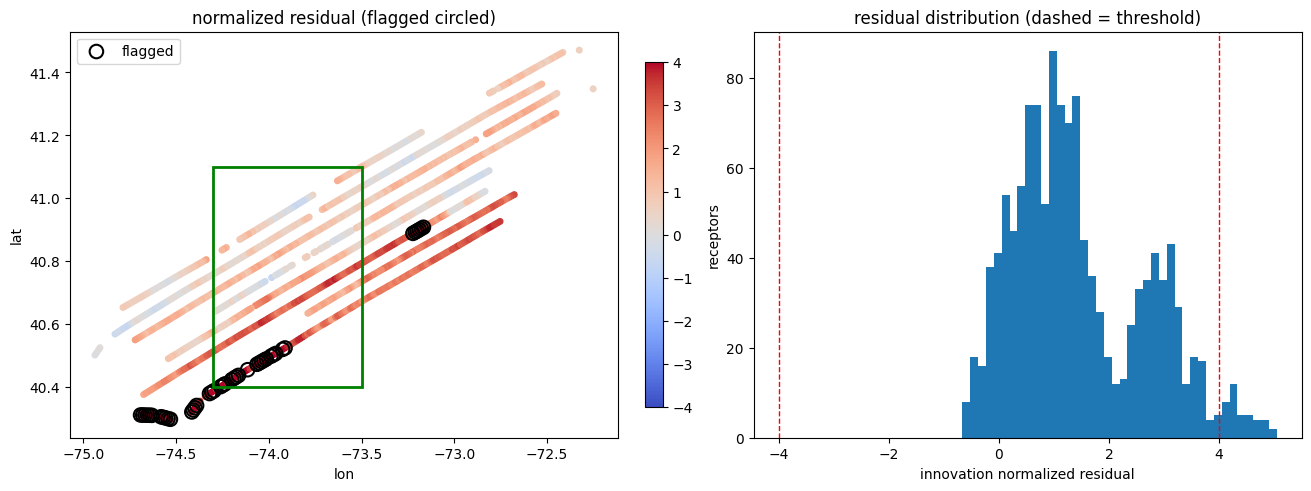

In [13]:
from goe import flag_outliers

OUTLIER_THRESHOLD = cfg.get_float('observations', 'outlier_threshold', default=0.0) or 4.0
OUTLIER_KIND = cfg.get('observations', 'outlier_kind', default='innovation')

# per-receptor boolean flag + normalized residuals
outlier_mask, nr = flag_outliers(prob_corr, posterior=post_corr,
                                 threshold=OUTLIER_THRESHOLD, kind=OUTLIER_KIND)
print(f'{int(outlier_mask.sum())} of {len(outlier_mask)} receptors flagged '
      f'(|{OUTLIER_KIND} residual| > {OUTLIER_THRESHOLD})')
print("`outlier_mask` is the per-receptor flag (save/plot it). The pipeline returns it as")
print("res.outlier_mask, and run_halo.py writes it to the output netCDF as 'outlier_flag'.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
sc = ax[0].scatter(rlon, rlat, c=nr, s=16, cmap='coolwarm',
                   vmin=-OUTLIER_THRESHOLD, vmax=OUTLIER_THRESHOLD)
ax[0].scatter(rlon[outlier_mask], rlat[outlier_mask], s=95, facecolors='none',
              edgecolors='k', linewidths=1.5, label='flagged')
ax[0].add_patch(plt.Rectangle((BBOX[2], BBOX[0]), BBOX[3]-BBOX[2], BBOX[1]-BBOX[0],
                              fill=False, ec='green', lw=2))
ax[0].set_xlabel('lon'); ax[0].set_ylabel('lat'); ax[0].legend(loc='upper left')
ax[0].set_title('normalized residual (flagged circled)'); fig.colorbar(sc, ax=ax[0], shrink=0.85)
ax[1].hist(nr, bins=40)
for s in (-OUTLIER_THRESHOLD, OUTLIER_THRESHOLD):
    ax[1].axvline(s, color='r', ls='--', lw=1)
ax[1].set_xlabel(f'{OUTLIER_KIND} normalized residual'); ax[1].set_ylabel('receptors')
ax[1].set_title('residual distribution (dashed = threshold)')
plt.show()

## 9. Posterior scalars (primary inventory)

Values near 1 leave the inventory unchanged; the posterior relaxes to the prior where the data lack sensitivity (uncertainty map).

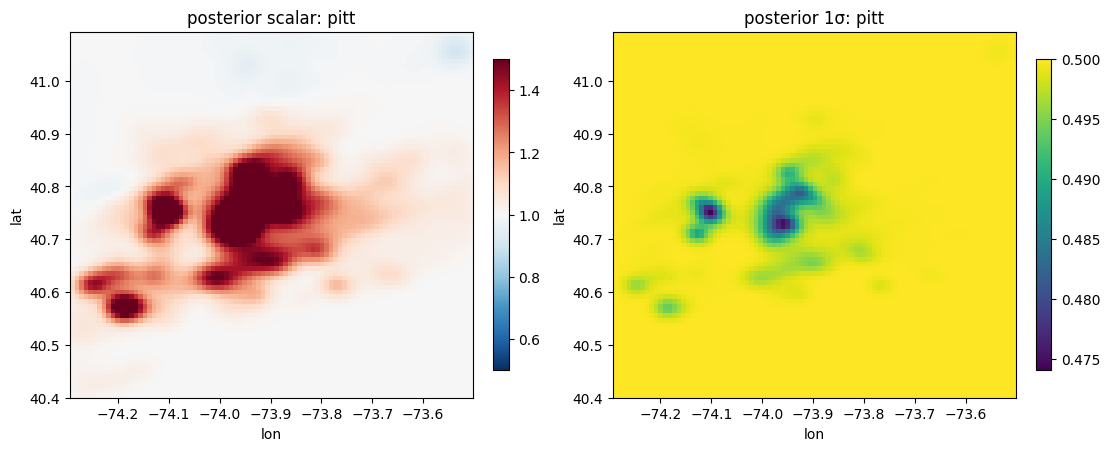

In [14]:
parts = state.unpack(posterior.mean); stds = state.unpack(posterior.stddev())
sfield = crop(core.to_field(parts[INVENTORY])); ufield = crop(core.to_field(stds[INVENTORY]))
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
im0 = ax[0].imshow(sfield, origin='lower', extent=EXTENT, aspect='auto', cmap='RdBu_r', vmin=0.5, vmax=1.5)
ax[0].set_title(f'posterior scalar: {INVENTORY}'); fig.colorbar(im0, ax=ax[0], shrink=0.85)
im1 = ax[1].imshow(ufield, origin='lower', extent=EXTENT, aspect='auto', cmap='viridis')
ax[1].set_title(f'posterior 1\u03c3: {INVENTORY}'); fig.colorbar(im1, ax=ax[1], shrink=0.85)
for a in ax: a.set_xlabel('lon'); a.set_ylabel('lat')
plt.show()

## 10. Integrated flux (primary inventory)

Integrate `scalar x prior x cell-area` -> total emission, prior vs posterior, with uncertainty from the posterior covariance. Native units until `unit_scale` is set.

In [15]:
report = estimate_fluxes(posterior, state, core, {INVENTORY: priors[INVENTORY]}, grid, prior_state=xa,
                         unit_scale=cfg.get_float('flux', 'unit_scale', default=1.0),
                         unit_label=cfg.get('flux', 'unit_label', default='prior-units x m^2 (native)'))
print(report.as_table())

category              prior      posterior         ± 1σ    scale
----------------------------------------------------------------
pitt              2.467e+08      3.399e+08    1.106e+07    1.378

units: prior-units x m^2 (native)


## 11. Compare inventories (prior sensitivity)

EDGAR, EPA, Pittsburgh are alternative priors, so invert each **separately** (reusing the same Jacobian read) and compare posterior totals. The spread measures prior dependence — they are **not** summed.

inventory           prior      posterior          ±1σ    scale   chi2_r
----------------------------------------------------------------------
edgar           1.453e+08      1.829e+08     7.93e+06    1.258    3.386
epa             1.301e+08      1.497e+08    4.884e+06    1.150    3.406
pitt            2.467e+08      3.399e+08    1.106e+07    1.378    3.211


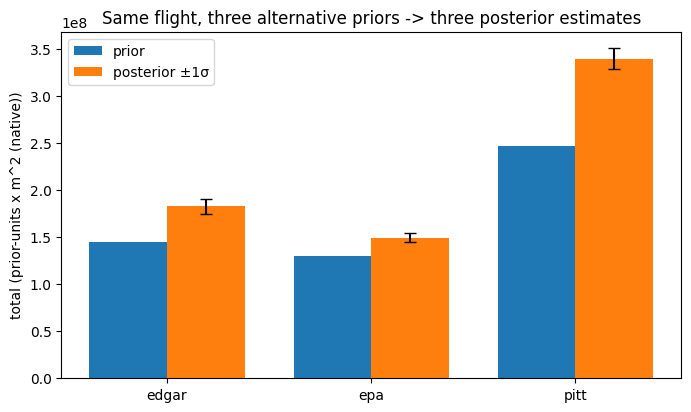

In [16]:
ctx = InversionContext(cfg=cfg, grid=grid, core=core, base=base,
                       background=bg, obs=obs_data, priors=priors,
                       jfs=[jf], flight_ids=[FLIGHT_ID],
                       flight_index=np.zeros(jf.n_receptors, dtype=int))
results = {inv: invert(ctx, inv) for inv in COMPARE}

print(f"{'inventory':<10} {'prior':>14} {'posterior':>14} {'±1σ':>12} {'scale':>8} {'chi2_r':>8}")
print('-'*70)
for inv in COMPARE:
    r = results[inv].report
    print(f'{inv:<10} {r.prior[0]:>14.4g} {r.posterior[0]:>14.4g} {r.posterior_stddev[0]:>12.4g} '
          f'{r.scale_factor[0]:>8.3f} {results[inv].diagnostics["reduced_chi_square"]:>8.3f}')

x = np.arange(len(COMPARE)); w = 0.38
pri = [results[i].report.prior[0] for i in COMPARE]; pos = [results[i].report.posterior[0] for i in COMPARE]
err = [results[i].report.posterior_stddev[0] for i in COMPARE]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, pri, w, label='prior'); ax.bar(x + w/2, pos, w, yerr=err, capsize=4, label='posterior ±1σ')
ax.set_xticks(x); ax.set_xticklabels(COMPARE); ax.set_ylabel(f'total ({report.unit_label})')
ax.set_title('Same flight, three alternative priors -> three posterior estimates'); ax.legend(); plt.show()

## 12. Sectoral decomposition (one inventory → super-categories)

Within **one** inventory, sub-categories (natural gas, landfill, wastewater, …) are *additive* sectors that sum to the inventory total, so the posterior can be decomposed by sector. Sub-categories are grouped into configurable super-categories (`[category_groups]`), and three attribution methods are available (`[decomposition] method`):

* **`partition`** — solve the per-cell total; split post-hoc by *prior* category variance (data constrain the total).
* **`category_fields`** *(recommended, shown here)* — solve a per-cell scalar field **per category**, each with an error structure matched to its source type: **diagonal** for point sources with known locations (landfills, WWTPs — only magnitude uncertain), **spatial** (modest decorrelation length) for diffuse / spatially-uncertain sources (natural gas distribution, area combustion). Data-informed and well-posed.
* **`category_scalars`** — domain scalar per category + per-cell total correction (weakly identified from a single flight; prior-sensitive).

Caveat: column data poorly separate *co-located* categories (shared footprint), so the prior sigmas and per-category covariances do real work, and single-flight information content (DOFS) is low. The decomposition reuses the same Jacobian read via `invert`.

In [17]:
res = invert(ctx, INVENTORY, decompose=True, method=METHOD)
print(f'inventory {INVENTORY} | method {res.mode} | reduced chi2 {res.diagnostics["reduced_chi_square"]:.3f}')

# show the grouping and each category's prior-error structure
groups = {}
for label, g in res.assignment.items():
    groups.setdefault(g, []).append(label)
default_corr = cfg.get_float('category_spatial', 'default', default=0.0)
print('\nsuper-category            sub-cats   prior-error structure')
for g, labs in groups.items():
    corr = cfg.get_float('category_spatial', g, default=default_corr)
    kind = f'spatial ({corr:.0f} km decorrelation)' if corr and corr > 0 else 'diagonal (point source)'
    print(f'  {g:<22} {len(labs):>4}     {kind}')
print('\n' + res.report.as_table())

inventory pitt | method category_fields | reduced chi2 3.245

super-category            sub-cats   prior-error structure
  natural_gas               3     spatial (5 km decorrelation)
  other                     3     diagonal (point source)
  combustion                2     spatial (5 km decorrelation)
  wastewater                1     diagonal (point source)
  landfill                  1     diagonal (point source)

category              prior      posterior         ± 1σ    scale
----------------------------------------------------------------
natural_gas       1.555e+08      1.955e+08    7.497e+06    1.257
landfill          2.615e+07      2.845e+07    1.784e+06    1.088
wastewater         4.33e+07      4.607e+07    1.916e+06    1.064
combustion        1.316e+07      1.383e+07    9.888e+05    1.051
other             8.569e+06      8.572e+06    8.367e+04    1.000
total             2.467e+08      2.924e+08    7.887e+06    1.185

units: prior-units x m^2 (native)


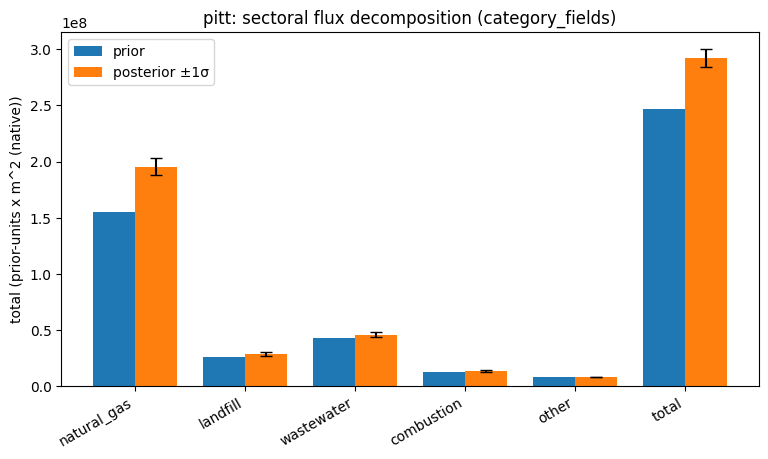

In [18]:
r = res.report
x = np.arange(len(r.names)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(x - w/2, r.prior, w, label='prior')
ax.bar(x + w/2, r.posterior, w, yerr=r.posterior_stddev, capsize=4, label='posterior \u00b11\u03c3')
ax.set_xticks(x); ax.set_xticklabels(r.names, rotation=30, ha='right')
ax.set_ylabel(f'total ({r.unit_label})')
ax.set_title(f'{INVENTORY}: sectoral flux decomposition ({res.mode})'); ax.legend(); plt.show()

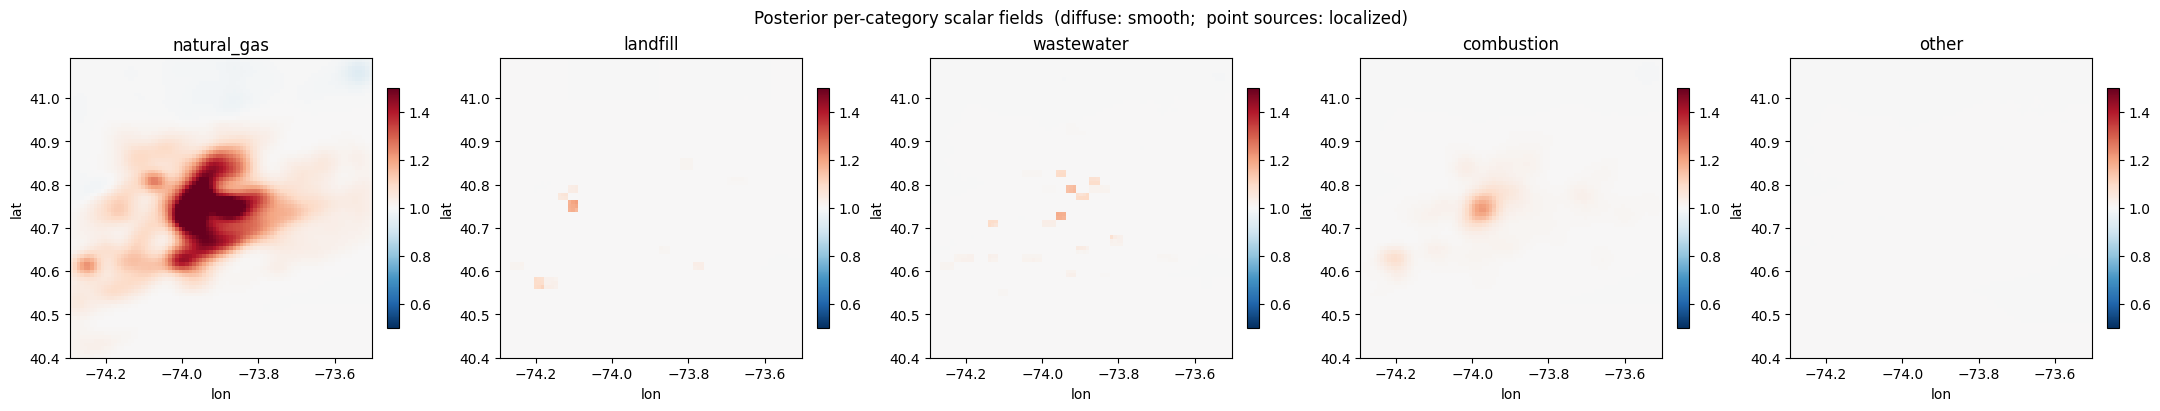

In [19]:
# per-category posterior scalar fields (only when fields are solved per category)
if res.mode == 'category_fields':
    parts = res.state.unpack(res.posterior.mean)
    cats = [b.name for b in res.state.blocks if b.name != 'bc']
    fig, ax = plt.subplots(1, len(cats), figsize=(4.3*len(cats), 4), constrained_layout=True)
    ax = np.atleast_1d(ax)
    for a, name in zip(ax, cats):
        fld = crop(core.to_field(parts[name]))
        im = a.imshow(fld, origin='lower', extent=EXTENT, aspect='auto', cmap='RdBu_r', vmin=0.5, vmax=1.5)
        a.set_title(name); a.set_xlabel('lon'); a.set_ylabel('lat'); fig.colorbar(im, ax=a, shrink=0.8)
    fig.suptitle('Posterior per-category scalar fields  (diffuse: smooth;  point sources: localized)')
    plt.show()
else:
    print(f'method {res.mode!r} does not solve per-category fields; see the table/bars above.')

## Where this stands, and what's next

This walkthrough showed **one flight** end to end: observations → per-flight planar background (domain-insensitive) → enhancements → masked operator → single-inventory state + spatial prior → solve → model-data-mismatch & error tuning → outlier flagging → posterior maps → integrated flux → inventory comparison → sectoral decomposition. All settings came from `halo_oe/config.ini`, matching the `run_halo.py` CLI.

**Multi-flight assimilation is available** — the flux state is shared across flights, each flight contributing its own observation rows (`goe.BlockRow`), background, error covariance, and background offset. Run a single day or any combination:

```bash
python -m halo_oe.run_halo halo_oe/config.ini --flights 20230726_1
python -m halo_oe.run_halo halo_oe/config.ini --flights 20230726_1,20230726_2,20230728_1
```

or set `[jacobian] flights` in the config, or call `load_context(cfg, ["pitt"], flights=[...])`.

Remaining toward a defensible number:

1. **Experiments across flight combinations** — multi-flight raises DOFS and is the key to identifying the `R`/`Sa` error split and trustworthy attribution.
2. **Domain + buffer** — enlarge the core and add a coarse buffer ring.
3. **Error budget** — fit the MDM magnitude and correlation length (step 8b, `--tune`) with multi-flight data.
4. **Units** — confirm inventory units; set `[flux] unit_scale` to report e.g. kt CH4 / yr.
5. **Sensitivity** — vary background quantile, prior widths, correlation lengths, MDM correlation length, category grouping, and per-category covariance choices.